
# ============================================================
#  IMPROVED PADDY SEED DETECTION MODEL — Google Colab
#  Features: Dual Dataset Fusion | ResNet50 | Physical Parameters | DUS Integration | Enhanced Testing
#  Author  : Enhanced Version
#  Classes : Healthy Paddy Seeds | Damaged Seeds | Fake/Low Quality Seeds
# ============================================================

# ─────────────────────────────────────────────────────────────

In [1]:
# CELL 1 ── Install / Import Dependencies
# ─────────────────────────────────────────────────────────────
# Run this cell first in Colab

# !pip install torch torchvision matplotlib scikit-learn seaborn tqdm pillow opencv-python kagglehub pandas

import os, random, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, ConcatDataset
from torchvision import transforms, models, datasets
from torchvision.utils import make_grid

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from PIL import Image
from tqdm import tqdm

# ── Reproducibility
SEED = 42
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)

# ── Device (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅  Using device: {DEVICE}")


# ─────────────────────────────────────────────────────────────


✅  Using device: cuda


In [2]:
# CELL 1A ── DUS PARAMETERS ADDON MODULE (INTEGRATED)
# ─────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("  LOADING DUS PHYSICAL TESTING PARAMETERS MODULE")
print("="*70)

# ── DUS REFERENCE DATABASE
dus_data = {
    "Variety": [
        "CAU-R1", "RCM-5", "SARS-6", "SARS-1", "KBA BAH", "KBA LWAI",
        "IDAW-2", "BUH SAKAI", "MANYA", "ZHUTSSOK", "SOMPOURO EPHYO", "MOTSO"
    ],
    "Weight_1000g_g": [
        29.04, 26.20, 26.65, 29.10, 33.57, 31.45,
        29.20, 29.53, 22.41, 33.19, 44.33, 36.75
    ],
    "Grain_Length_mm": [
        9.56, 9.22, 9.32, 8.64, 8.62, 8.01,
        10.62, 9.29, 8.23, 8.94, 11.30, 9.12
    ],
    "Grain_Width_mm": [
        2.93, 3.01, 2.65, 3.23, 3.48, 3.66,
        2.87, 2.93, 2.93, 3.66, 3.72, 3.66
    ],
    "Decorticated_Length_mm": [
        6.81, 6.16, 6.72, 6.66, 6.09, 6.23,
        7.19, 6.49, 5.55, 6.32, 7.91, 6.57
    ],
    "Decorticated_Width_mm": [
        2.41, 2.40, 2.32, 2.93, 3.02, 3.14,
        2.25, 2.52, 2.38, 2.95, 2.57, 3.13
    ],
    "Decorticated_Shape": [
        "Long slender*", "Medium slender", "Long slender*", "Long slender",
        "Long bold", "Long bold", "Long slender*", "Long slender",
        "Short slender", "Long slender", "Extra long slender", "Long bold"
    ],
    "Decorticated_Colour": [
        "White", "White", "Red", "Light brown", "Red", "Light red",
        "White", "White", "Light red", "White", "Red", "White"
    ]
}

df_dus = pd.DataFrame(dus_data)

print(f"\n✅  DUS Reference Database: {len(df_dus)} varieties loaded")

# Compute derived features for DUS dataset
df_dus['Aspect_Ratio'] = df_dus['Grain_Length_mm'] / df_dus['Grain_Width_mm']
df_dus['Decorticated_Ratio'] = df_dus['Decorticated_Length_mm'] / df_dus['Decorticated_Width_mm']

print("\nDUS Dataset Summary:")
print(df_dus[['Variety', 'Weight_1000g_g', 'Grain_Length_mm', 'Grain_Width_mm', 'Aspect_Ratio']].head(3).to_string(index=False))
print("...")


# ── DUS CLASSIFICATION GUIDELINES
grain_weight_mapping = {
    "Very low": lambda x: x < 15.0,
    "Low": lambda x: 15.0 <= x <= 20.0,
    "Medium": lambda x: 20.0 < x <= 25.0,
    "High": lambda x: 25.0 < x <= 30.0,
    "Very high": lambda x: x > 30.0
}

grain_length_mapping = {
    "Very short": lambda x: x < 6.0,
    "Short": lambda x: 6.0 <= x <= 8.5,
    "Medium": lambda x: 8.5 < x <= 10.5,
    "Long": lambda x: 10.5 < x <= 12.5,
    "Very long": lambda x: x > 12.5
}

grain_width_mapping = {
    "Very narrow": lambda x: x < 2.0,
    "Narrow": lambda x: 2.0 <= x <= 2.5,
    "Medium": lambda x: 2.5 < x <= 3.0,
    "Broad": lambda x: 3.0 < x <= 3.5,
    "Very broad": lambda x: x > 3.5
}


def classify_dus_parameter(value, mapping_dict):
    """Classify parameter according to DUS guidelines."""
    for category, condition in mapping_dict.items():
        if condition(value):
            return category
    return "Unknown"


def classify_grain_shape(length, width):
    """Classify grain shape based on length/width ratio."""
    if width == 0:
        return "Unknown"
    ratio = length / width
    
    if ratio >= 3.0:
        if length > 10.5:
            return "Extra long slender"
        elif length > 8.5:
            return "Long slender"
        else:
            return "Medium slender"
    elif ratio >= 2.0:
        if length > 8.5:
            return "Long medium"
        else:
            return "Medium"
    else:
        if length > 8.5:
            return "Long bold"
        else:
            return "Short bold"


def get_dus_classification(weight_1000g, grain_length, grain_width):
    """Get complete DUS classification for grain sample."""
    return {
        "weight_class": classify_dus_parameter(weight_1000g, grain_weight_mapping),
        "length_class": classify_dus_parameter(grain_length, grain_length_mapping),
        "width_class": classify_dus_parameter(grain_width, grain_width_mapping),
        "shape_class": classify_grain_shape(grain_length, grain_width),
        "length_width_ratio": grain_length / grain_width if grain_width > 0 else 0,
        "weight_1000g": weight_1000g,
        "length_mm": grain_length,
        "width_mm": grain_width
    }

print("\n✅  DUS Classification Guidelines loaded")
print("    Categories: Weight (5 classes) | Length (5 classes) | Width (5 classes)")


# ── PIXEL-TO-PHYSICAL CONVERTER
class PixelToPhysicalConverter:
    """Convert CV pixel measurements to physical units (mm, grams)."""
    
    def __init__(self, pixel_to_mm_ratio=0.05):
        """
        Initialize with calibration ratio.
        
        IMPORTANT: Calibrate this value for your imaging setup!
        - Smartphone at 20cm: ~0.05 mm/pixel
        - Flatbed scanner 300 DPI: ~0.0847 mm/pixel
        - High-res camera: ~0.01-0.03 mm/pixel
        
        To calibrate:
        1. Place object of known size (e.g., 10mm ruler) in image
        2. Measure pixels
        3. ratio = known_mm / measured_pixels
        """
        self.pixel_to_mm = pixel_to_mm_ratio
        self.grain_density = 0.0014  # g/mm³ (average rice)
        self.avg_thickness_mm = 2.0   # Assumed grain thickness
        
        print(f"\n✅  Pixel-Physical Converter initialized")
        print(f"    Calibration: 1 pixel = {self.pixel_to_mm} mm")
        print(f"    ⚠️  Adjust pixel_to_mm_ratio for your camera setup!")
    
    def pixels_to_mm(self, pixels):
        """Convert pixels to millimeters."""
        return pixels * self.pixel_to_mm
    
    def estimate_volume_mm3(self, length_mm, width_mm):
        """Estimate grain volume (ellipsoid approximation)."""
        a = length_mm / 2
        b = width_mm / 2
        c = self.avg_thickness_mm / 2
        return (4/3) * np.pi * a * b * c
    
    def estimate_1000_grain_weight_g(self, length_mm, width_mm):
        """Estimate 1000-grain weight."""
        volume = self.estimate_volume_mm3(length_mm, width_mm)
        single_grain_g = volume * self.grain_density
        return single_grain_g * 1000
    
    def convert_cv_to_physical(self, cv_params):
        """
        Convert CV parameters (pixels) to physical parameters (mm, g).
        
        Input: cv_params from PhysicalParameterExtractor
        Output: Physical measurements + DUS classification
        """
        # Convert dimensions
        length_mm = self.pixels_to_mm(cv_params['length'])
        width_mm = self.pixels_to_mm(cv_params['width'])
        area_mm2 = (self.pixel_to_mm ** 2) * cv_params['area']
        
        # Estimate weight
        weight_1000g = self.estimate_1000_grain_weight_g(length_mm, width_mm)
        
        # Get DUS classification
        dus_class = get_dus_classification(weight_1000g, length_mm, width_mm)
        
        return {
            # Physical measurements
            'grain_length_mm': length_mm,
            'grain_width_mm': width_mm,
            'grain_area_mm2': area_mm2,
            'weight_1000g_estimated': weight_1000g,
            'aspect_ratio': cv_params['aspect_ratio'],
            
            # DUS classifications
            'dus_weight_class': dus_class['weight_class'],
            'dus_length_class': dus_class['length_class'],
            'dus_width_class': dus_class['width_class'],
            'dus_shape_class': dus_class['shape_class'],
            
            # Shape features (preserved from CV)
            'circularity': cv_params['circularity'],
            'solidity': cv_params['solidity'],
            'convexity': cv_params['convexity'],
            
            # Color features (preserved from CV)
            'brightness': cv_params['brightness'],
            'mean_red': cv_params['mean_red'],
            'mean_green': cv_params['mean_green'],
            'mean_blue': cv_params['mean_blue'],
            
            # Texture features (preserved from CV)
            'texture_variance': cv_params['texture_variance'],
            'entropy': cv_params['entropy']
        }
    
    def match_to_dus_variety(self, physical_params, top_k=3):
        """
        Find closest matching varieties in DUS database.
        Uses Euclidean distance on normalized features.
        """
        # Extract key features for matching
        query_features = np.array([
            physical_params['weight_1000g_estimated'],
            physical_params['grain_length_mm'],
            physical_params['grain_width_mm'],
            physical_params['aspect_ratio']
        ]).reshape(1, -1)
        
        # Get reference features from DUS database
        ref_features = df_dus[['Weight_1000g_g', 'Grain_Length_mm', 
                                'Grain_Width_mm', 'Aspect_Ratio']].values
        
        # Normalize
        scaler = StandardScaler()
        ref_norm = scaler.fit_transform(ref_features)
        query_norm = scaler.transform(query_features)
        
        # Compute distances
        distances = np.linalg.norm(ref_norm - query_norm, axis=1)
        
        # Get top K matches
        top_indices = np.argsort(distances)[:top_k]
        
        matches = []
        for idx in top_indices:
            matches.append({
                'variety': df_dus.iloc[idx]['Variety'],
                'distance': distances[idx],
                'similarity': 1 / (1 + distances[idx]),  # Convert to similarity score
                'reference_weight': df_dus.iloc[idx]['Weight_1000g_g'],
                'reference_length': df_dus.iloc[idx]['Grain_Length_mm'],
                'reference_width': df_dus.iloc[idx]['Grain_Width_mm']
            })
        
        return matches

# Initialize converter with default calibration
# IMPORTANT: Adjust pixel_to_mm_ratio based on your imaging setup!
converter = PixelToPhysicalConverter(pixel_to_mm_ratio=0.05)


# ── VISUALIZATION FUNCTIONS FOR DUS PARAMETERS
def visualize_dus_comparison(physical_params, dus_matches):
    """
    Visualize how the detected grain compares to DUS reference varieties.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Extract data for plotting
    varieties = [m['variety'] for m in dus_matches]
    detected_params = [
        physical_params['weight_1000g_estimated'],
        physical_params['grain_length_mm'],
        physical_params['grain_width_mm']
    ]
    
    # Parameter 1: Weight
    ref_weights = [m['reference_weight'] for m in dus_matches]
    axes[0].bar(varieties, ref_weights, alpha=0.6, label='DUS Reference')
    axes[0].axhline(detected_params[0], color='red', linestyle='--', 
                    linewidth=2, label='Detected')
    axes[0].set_ylabel('Weight (g/1000 grains)')
    axes[0].set_title('1000-Grain Weight Comparison', fontweight='bold')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(alpha=0.3)
    
    # Parameter 2: Length
    ref_lengths = [m['reference_length'] for m in dus_matches]
    axes[1].bar(varieties, ref_lengths, alpha=0.6, label='DUS Reference')
    axes[1].axhline(detected_params[1], color='red', linestyle='--',
                    linewidth=2, label='Detected')
    axes[1].set_ylabel('Length (mm)')
    axes[1].set_title('Grain Length Comparison', fontweight='bold')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(alpha=0.3)
    
    # Parameter 3: Width
    ref_widths = [m['reference_width'] for m in dus_matches]
    axes[2].bar(varieties, ref_widths, alpha=0.6, label='DUS Reference')
    axes[2].axhline(detected_params[2], color='red', linestyle='--',
                    linewidth=2, label='Detected')
    axes[2].set_ylabel('Width (mm)')
    axes[2].set_title('Grain Width Comparison', fontweight='bold')
    axes[2].legend()
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_dus_report(physical_params, dus_matches):
    """Print a formatted DUS testing report."""
    print("\n" + "="*70)
    print("  DUS PHYSICAL TESTING REPORT")
    print("="*70)
    
    print("\n📏  MEASURED PHYSICAL PARAMETERS:")
    print(f"  1000-Grain Weight : {physical_params['weight_1000g_estimated']:.2f} g")
    print(f"  Grain Length      : {physical_params['grain_length_mm']:.2f} mm")
    print(f"  Grain Width       : {physical_params['grain_width_mm']:.2f} mm")
    print(f"  Aspect Ratio      : {physical_params['aspect_ratio']:.2f}")
    
    print("\n📊  DUS CLASSIFICATIONS:")
    print(f"  Weight Class      : {physical_params['dus_weight_class']}")
    print(f"  Length Class      : {physical_params['dus_length_class']}")
    print(f"  Width Class       : {physical_params['dus_width_class']}")
    print(f"  Shape Class       : {physical_params['dus_shape_class']}")
    
    print("\n🔍  CLOSEST MATCHING VARIETIES (DUS Database):")
    print(f"  {'Rank':<6} {'Variety':<20} {'Similarity':<12} {'Δ Weight':<12} {'Δ Length':<12}")
    print("  " + "-"*66)
    
    for i, match in enumerate(dus_matches, 1):
        delta_weight = abs(physical_params['weight_1000g_estimated'] - match['reference_weight'])
        delta_length = abs(physical_params['grain_length_mm'] - match['reference_length'])
        similarity_pct = match['similarity'] * 100
        
        print(f"  {i:<6} {match['variety']:<20} {similarity_pct:>10.1f}%  "
              f"{delta_weight:>10.2f}g  {delta_length:>10.2f}mm")
    
    print("="*70)

# ── ENHANCED PREDICTION WITH DUS INTEGRATION
def predict_with_dus_parameters(image_path, model, param_extractor, 
                                show_plots=True, show_dus_report=True):
    """
    Enhanced prediction function that includes:
    1. CNN-based classification
    2. CV parameter extraction
    3. Physical parameter conversion
    4. DUS classification
    5. Variety matching
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    
    # 1. CNN Prediction
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        pred_class = CLASS_NAMES[pred_idx]
        pred_confidence = probs[pred_idx].item()
    
    # 2. Extract CV parameters
    cv_params = param_extractor.extract_parameters(image_path)
    
    # 3. Convert to physical parameters
    physical_params = converter.convert_cv_to_physical(cv_params)
    
    # 4. Match to DUS varieties
    dus_matches = converter.match_to_dus_variety(physical_params, top_k=3)
    
    # Display results
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Show image with prediction
        axes[0].imshow(img)
        axes[0].set_title(f"Predicted: {pred_class}\nConfidence: {pred_confidence*100:.1f}%\n"
                         f"DUS Shape: {physical_params['dus_shape_class']}",
                         fontweight='bold', fontsize=10)
        axes[0].axis('off')
        
        # Show class probabilities
        bars = axes[1].barh(CLASS_NAMES, [probs[i].item()*100 for i in range(NUM_CLASSES)])
        axes[1].set_xlabel('Probability (%)')
        axes[1].set_title('Classification Confidence', fontweight='bold')
        axes[1].set_xlim([0, 100])
        bars[pred_idx].set_color('green')
        
        plt.tight_layout()
        plt.show()
        
        # Show DUS comparison
        visualize_dus_comparison(physical_params, dus_matches)
    
    # Print detailed report
    if show_dus_report:
        print_dus_report(physical_params, dus_matches)
    
    return {
        'cnn_prediction': pred_class,
        'cnn_confidence': pred_confidence,
        'cnn_probabilities': {CLASS_NAMES[i]: probs[i].item() for i in range(NUM_CLASSES)},
        'cv_parameters': cv_params,
        'physical_parameters': physical_params,
        'dus_matches': dus_matches
    }

print("\n" + "="*70)
print("  DUS PARAMETERS MODULE LOADED SUCCESSFULLY")
print("="*70)
print("\nNew functions available:")
print("  • predict_with_dus_parameters() - Enhanced prediction with DUS")
print("  • get_dus_classification() - Classify any grain measurement")
print("  • converter.convert_cv_to_physical() - Convert pixels to mm/g")
print("  • converter.match_to_dus_variety() - Find matching varieties")
print("\n⚠️  IMPORTANT: Calibrate pixel_to_mm_ratio for your camera!")
print("="*70)


# ─────────────────────────────────────────────────────────────



  LOADING DUS PHYSICAL TESTING PARAMETERS MODULE

✅  DUS Reference Database: 12 varieties loaded

DUS Dataset Summary:
Variety  Weight_1000g_g  Grain_Length_mm  Grain_Width_mm  Aspect_Ratio
 CAU-R1           29.04             9.56            2.93      3.262799
  RCM-5           26.20             9.22            3.01      3.063123
 SARS-6           26.65             9.32            2.65      3.516981
...

✅  DUS Classification Guidelines loaded
    Categories: Weight (5 classes) | Length (5 classes) | Width (5 classes)

✅  Pixel-Physical Converter initialized
    Calibration: 1 pixel = 0.05 mm
    ⚠️  Adjust pixel_to_mm_ratio for your camera setup!

  DUS PARAMETERS MODULE LOADED SUCCESSFULLY

New functions available:
  • predict_with_dus_parameters() - Enhanced prediction with DUS
  • get_dus_classification() - Classify any grain measurement
  • converter.convert_cv_to_physical() - Convert pixels to mm/g
  • converter.match_to_dus_variety() - Find matching varieties

⚠️  IMPORTANT: Ca

In [ ]:
# CELL 2 ── Download BOTH Datasets from Kaggle
# ─────────────────────────────────────────────────────────────

# !pip install kagglehub -q

import kagglehub
import shutil

print("="*70)
print("  DOWNLOADING BOTH PADDY SEED DATASETS")
print("="*70)

# ── Dataset 1: ayyanarkadalkani/paddy-seeds-quality-classification-dataset
print("\n⬇️  Dataset 1: Quality Classification Dataset...")
DATASET1_PATH = kagglehub.dataset_download(
    "ayyanarkadalkani/paddy-seeds-quality-classification-dataset"
)
print(f"✅  Downloaded to: {DATASET1_PATH}")

# ── Dataset 2: Paddy Seed Image Dataset (search for exact name on Kaggle)
# Note: You may need to adjust the exact dataset name based on Kaggle
print("\n⬇️  Dataset 2: Paddy Seed Image Dataset...")
try:
    # Try common variations - adjust based on actual Kaggle dataset name
    DATASET2_PATH = kagglehub.dataset_download("nilambarelangbam/paddy-seed-images-collected-from-icar-manipur")
    print(f"✅  Downloaded to: {DATASET2_PATH}")
except Exception as e:
    print(f"⚠️  Could not find 'paddy-seed-image-dataset'. Error: {e}")
    print("Please verify the exact Kaggle dataset name and update line 66.")
    print("Proceeding with Dataset 1 only for now...")
    DATASET2_PATH = None

print("\n" + "="*70)


# ─────────────────────────────────────────────────────────────


  DOWNLOADING BOTH PADDY SEED DATASETS

⬇️  Dataset 1: Quality Classification Dataset...
Using Colab cache for faster access to the 'paddy-seeds-quality-classification-dataset' dataset.
✅  Downloaded to: /kaggle/input/paddy-seeds-quality-classification-dataset

⬇️  Dataset 2: Paddy Seed Image Dataset...
⚠️  Could not find 'paddy-seed-image-dataset'. Error: Invalid dataset handle: paddy-seed-image-dataset
Please verify the exact Kaggle dataset name and update line 66.
Proceeding with Dataset 1 only for now...



In [4]:
# CELL 3 ── Combine Both Datasets into Unified Structure
# ─────────────────────────────────────────────────────────────

def inspect_dataset_structure(base_path, dataset_name):
    """Inspect and print the folder structure of a dataset."""
    print(f"\n📂  {dataset_name} structure:")
    for root_dir, dirs, files in os.walk(base_path):
        level  = root_dir.replace(base_path, "").count(os.sep)
        indent = "    " * level
        if level < 3:
            print(f"{indent}{os.path.basename(root_dir)}/")
            if level < 2:
                for f in files[:3]:
                    print(f"{indent}    {f}")

inspect_dataset_structure(DATASET1_PATH, "Dataset 1")
if DATASET2_PATH:
    inspect_dataset_structure(DATASET2_PATH, "Dataset 2")


def find_data_directories(base_path):
    """
    Auto-detect train/val/test directories or class folders.
    Returns dict with 'train', 'val', 'test' paths or None if not found.
    """
    entries = os.listdir(base_path)
    result = {'train': None, 'val': None, 'test': None}
    
    # Check for nested structure (like 'Paddy Seeds Classification Dataset')
    for entry in entries:
        entry_path = os.path.join(base_path, entry)
        if os.path.isdir(entry_path):
            sub_entries = [e.lower() for e in os.listdir(entry_path)]
            
            # If this subfolder has train/val/test, use it
            if any('train' in e for e in sub_entries):
                base_path = entry_path
                entries = os.listdir(base_path)
                break
    
    # Now find train/val/test folders
    entries_lower = [e.lower() for e in entries]
    
    for entry, entry_lower in zip(entries, entries_lower):
        if 'train' in entry_lower:
            result['train'] = os.path.join(base_path, entry)
        elif entry_lower in ('val', 'valid', 'validation'):
            result['val'] = os.path.join(base_path, entry)
        elif 'test' in entry_lower:
            result['test'] = os.path.join(base_path, entry)
    
    return result


def combine_datasets(dataset1_dirs, dataset2_dirs, output_root="/content/combined_paddy_data"):
    """
    Combine two datasets into a unified train/val/test structure.
    Handles class name mapping and image copying.
    """
    print("\n🔄  Combining datasets into unified structure...")
    
    os.makedirs(output_root, exist_ok=True)
    splits = ['train', 'val', 'test']
    
    # Track combined statistics
    stats = defaultdict(lambda: defaultdict(int))
    
    for split in splits:
        print(f"\n  Processing {split} split...")
        
        # Collect all source directories for this split
        source_dirs = []
        if dataset1_dirs.get(split):
            source_dirs.append((dataset1_dirs[split], "Dataset1"))
        if dataset2_dirs and dataset2_dirs.get(split):
            source_dirs.append((dataset2_dirs[split], "Dataset2"))
        
        if not source_dirs:
            print(f"    ⚠️  No {split} data found in any dataset")
            continue
        
        # Get all class names across datasets
        all_classes = set()
        for src_dir, _ in source_dirs:
            if os.path.exists(src_dir):
                all_classes.update([d for d in os.listdir(src_dir) 
                                   if os.path.isdir(os.path.join(src_dir, d))])
        
        # Copy images from each source
        for src_dir, dataset_name in source_dirs:
            if not os.path.exists(src_dir):
                continue
                
            for class_name in os.listdir(src_dir):
                src_class_path = os.path.join(src_dir, class_name)
                if not os.path.isdir(src_class_path):
                    continue
                
                # Create destination directory
                dest_class_path = os.path.join(output_root, split, class_name)
                os.makedirs(dest_class_path, exist_ok=True)
                
                # Copy all images
                images = [f for f in os.listdir(src_class_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
                
                for img_file in images:
                    src_img = os.path.join(src_class_path, img_file)
                    # Add dataset prefix to avoid name conflicts
                    dest_img = os.path.join(dest_class_path, 
                                          f"{dataset_name}_{img_file}")
                    shutil.copy2(src_img, dest_img)
                    stats[split][class_name] += 1
    
    # Print statistics
    print("\n" + "="*70)
    print("  COMBINED DATASET STATISTICS")
    print("="*70)
    for split in splits:
        print(f"\n{split.upper()}:")
        if split in stats:
            for class_name, count in sorted(stats[split].items()):
                print(f"  {class_name:<35} : {count:>5} images")
        else:
            print("  No data")
    print("="*70)
    
    return output_root


# ── Get directories for both datasets
dataset1_dirs = find_data_directories(DATASET1_PATH)
dataset2_dirs = find_data_directories(DATASET2_PATH) if DATASET2_PATH else None

# ── Combine datasets
COMBINED_DATA_ROOT = combine_datasets(dataset1_dirs, dataset2_dirs)

# ── Set final paths
TRAIN_DIR = os.path.join(COMBINED_DATA_ROOT, 'train')
VAL_DIR = os.path.join(COMBINED_DATA_ROOT, 'val')
TEST_DIR = os.path.join(COMBINED_DATA_ROOT, 'test')

# ── Auto-detect class names
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n🌾  Final Classes detected ({NUM_CLASSES}):")
for i, cls in enumerate(CLASS_NAMES):
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"   [{i}] {cls:<35} — {count} images")


# ─────────────────────────────────────────────────────────────



📂  Dataset 1 structure:
paddy-seeds-quality-classification-dataset/
    Paddy Seeds Classification Dataset/
        validation/
        test/
        train/

🔄  Combining datasets into unified structure...

  Processing train split...

  Processing val split...

  Processing test split...

  COMBINED DATASET STATISTICS

TRAIN:
  impure                              :   647 images
  pure                                :   567 images

VAL:
  impure                              :    59 images
  pure                                :    59 images

TEST:
  impure                              :   107 images
  pure                                :   124 images

🌾  Final Classes detected (2):
   [0] impure                              — 1100 images
   [1] pure                                — 964 images


In [5]:
# CELL 4 ── Physical Parameter Extraction
#           Extract seed characteristics from images
# ─────────────────────────────────────────────────────────────

class PhysicalParameterExtractor:
    """
    Extract physical parameters from seed images:
    - Dimensions (length, width, area, perimeter, aspect ratio)
    - Color features (mean RGB, std RGB)
    - Shape descriptors (circularity, solidity)
    - Texture features (contrast, entropy)
    """
    
    def __init__(self):
        self.params_cache = {}
    
    def extract_parameters(self, image_path):
        """Extract all physical parameters from an image."""
        if image_path in self.params_cache:
            return self.params_cache[image_path]
        
        # Read image
        img = cv2.imread(image_path)
        if img is None:
            return self._default_params()
        
        # Convert to grayscale and RGB
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Extract all parameters
        params = {}
        params.update(self._extract_dimensions(gray))
        params.update(self._extract_color_features(rgb))
        params.update(self._extract_shape_features(gray))
        params.update(self._extract_texture_features(gray))
        
        self.params_cache[image_path] = params
        return params
    
    def _extract_dimensions(self, gray_img):
        """Extract dimensional parameters."""
        # Threshold to get seed region
        _, binary = cv2.threshold(gray_img, 0, 255, 
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, 
                                       cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return {'length': 0, 'width': 0, 'area': 0, 
                   'perimeter': 0, 'aspect_ratio': 1.0}
        
        # Get largest contour (assuming it's the seed)
        contour = max(contours, key=cv2.contourArea)
        
        # Calculate parameters
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        # Bounding rectangle for length and width
        rect = cv2.minAreaRect(contour)
        (x, y), (width, height), angle = rect
        
        length = max(width, height)
        width = min(width, height)
        aspect_ratio = length / width if width > 0 else 1.0
        
        return {
            'length': float(length),
            'width': float(width),
            'area': float(area),
            'perimeter': float(perimeter),
            'aspect_ratio': float(aspect_ratio)
        }
    
    def _extract_color_features(self, rgb_img):
        """Extract color statistics."""
        # Calculate mean and std for each channel
        mean_r, mean_g, mean_b = rgb_img.mean(axis=(0, 1))
        std_r, std_g, std_b = rgb_img.std(axis=(0, 1))
        
        return {
            'mean_red': float(mean_r),
            'mean_green': float(mean_g),
            'mean_blue': float(mean_b),
            'std_red': float(std_r),
            'std_green': float(std_g),
            'std_blue': float(std_b),
            'brightness': float((mean_r + mean_g + mean_b) / 3)
        }
    
    def _extract_shape_features(self, gray_img):
        """Extract shape descriptors."""
        _, binary = cv2.threshold(gray_img, 0, 255, 
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, 
                                       cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return {'circularity': 0, 'solidity': 0, 'convexity': 0}
        
        contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        # Circularity: 4π*area / perimeter²
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        
        # Solidity: area / convex hull area
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        # Convexity: convex hull perimeter / perimeter
        hull_perimeter = cv2.arcLength(hull, True)
        convexity = hull_perimeter / perimeter if perimeter > 0 else 0
        
        return {
            'circularity': float(circularity),
            'solidity': float(solidity),
            'convexity': float(convexity)
        }
    
    def _extract_texture_features(self, gray_img):
        """Extract simple texture features."""
        # Laplacian variance (sharpness/blur measure)
        laplacian_var = cv2.Laplacian(gray_img, cv2.CV_64F).var()
        
        # Histogram entropy (texture complexity)
        hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
        hist = hist / hist.sum()
        entropy = -np.sum(hist * np.log2(hist + 1e-10))
        
        return {
            'texture_variance': float(laplacian_var),
            'entropy': float(entropy)
        }
    
    def _default_params(self):
        """Return default parameters if extraction fails."""
        return {
            'length': 0, 'width': 0, 'area': 0, 'perimeter': 0, 
            'aspect_ratio': 1.0, 'mean_red': 0, 'mean_green': 0, 
            'mean_blue': 0, 'std_red': 0, 'std_green': 0, 'std_blue': 0,
            'brightness': 0, 'circularity': 0, 'solidity': 0, 
            'convexity': 0, 'texture_variance': 0, 'entropy': 0
        }


# ── Create extractor instance
param_extractor = PhysicalParameterExtractor()

print("\n✅  Physical parameter extractor initialized")
print("    Parameters extracted per image:")
print("    • Dimensional: length, width, area, perimeter, aspect_ratio")
print("    • Color: mean RGB, std RGB, brightness")
print("    • Shape: circularity, solidity, convexity")
print("    • Texture: variance, entropy")


# ─────────────────────────────────────────────────────────────



✅  Physical parameter extractor initialized
    Parameters extracted per image:
    • Dimensional: length, width, area, perimeter, aspect_ratio
    • Color: mean RGB, std RGB, brightness
    • Shape: circularity, solidity, convexity
    • Texture: variance, entropy


In [6]:
# CELL 5 ── Custom Dataset with Physical Parameters
# ─────────────────────────────────────────────────────────────

class PaddySeedDataset(Dataset):
    """
    Custom dataset that loads images and extracts physical parameters.
    """
    
    def __init__(self, image_folder_dataset, param_extractor, transform=None):
        self.dataset = image_folder_dataset
        self.param_extractor = param_extractor
        self.transform = transform
        
        # Pre-extract physical parameters for all images
        print(f"    Extracting physical parameters for {len(self.dataset)} images...")
        self.physical_params = []
        for idx in tqdm(range(len(self.dataset)), desc="    Parameters"):
            img_path, _ = self.dataset.samples[idx]
            params = self.param_extractor.extract_parameters(img_path)
            self.physical_params.append(params)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img_path, label = self.dataset.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        # Get pre-extracted parameters
        params = self.physical_params[idx]
        
        return image, label, params
    
    def get_image_folder_dataset(self):
        """Return the underlying ImageFolder dataset."""
        return self.dataset


# ─────────────────────────────────────────────────────────────


In [7]:
# CELL 6 ── Image Preprocessing & Data Augmentation
# ─────────────────────────────────────────────────────────────

IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

# ── Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, 
                          saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# ── Validation/Test transforms
eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# ── Create base ImageFolder datasets
print("\n⏳  Loading datasets with physical parameter extraction...")
base_train = datasets.ImageFolder(TRAIN_DIR, transform=None)
base_val = datasets.ImageFolder(VAL_DIR, transform=None)
base_test = datasets.ImageFolder(TEST_DIR, transform=None)

# ── Wrap with physical parameter extraction
train_dataset = PaddySeedDataset(base_train, param_extractor, train_transforms)
val_dataset = PaddySeedDataset(base_val, param_extractor, eval_transforms)
test_dataset = PaddySeedDataset(base_test, param_extractor, eval_transforms)

# ── Class weights for balanced training
class_counts = np.array([
    len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES
])
class_weights = 1.0 / class_counts

# Build sample weights
sample_weights = [class_weights[label] 
                 for _, label in train_dataset.get_image_folder_dataset().samples]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# ── Custom collate function to handle physical parameters
def collate_with_params(batch):
    """Collate function that separates images, labels, and parameters."""
    images, labels, params = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    # params is a list of dicts - convert to dict of tensors
    param_dict = {}
    for key in params[0].keys():
        param_dict[key] = torch.tensor([p[key] for p in params], dtype=torch.float32)
    return images, labels, param_dict

# ── DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                         sampler=sampler, num_workers=NUM_WORKERS,
                         pin_memory=True, collate_fn=collate_with_params)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                       shuffle=False, num_workers=NUM_WORKERS,
                       collate_fn=collate_with_params)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS,
                        collate_fn=collate_with_params)

print(f"\n{'─'*60}")
print(f"  Train  : {len(train_dataset):>5} images (with physical params)")
print(f"  Val    : {len(val_dataset):>5} images (with physical params)")
print(f"  Test   : {len(test_dataset):>5} images (with physical params)")
print(f"  Classes: {CLASS_NAMES}")
print(f"{'─'*60}")


# ─────────────────────────────────────────────────────────────



⏳  Loading datasets with physical parameter extraction...
    Extracting physical parameters for 2064 images...


    Parameters: 100%|██████████| 2064/2064 [01:53<00:00, 18.23it/s]


    Extracting physical parameters for 300 images...


    Parameters: 100%|██████████| 300/300 [00:16<00:00, 18.40it/s]


    Extracting physical parameters for 413 images...


    Parameters: 100%|██████████| 413/413 [00:22<00:00, 18.45it/s]


────────────────────────────────────────────────────────────
  Train  :  2064 images (with physical params)
  Val    :   300 images (with physical params)
  Test   :   413 images (with physical params)
  Classes: ['impure', 'pure']
────────────────────────────────────────────────────────────



  PHYSICAL PARAMETER ANALYSIS BY CLASS

Parameter            | Class                          | Mean         | Std         
--------------------------------------------------------------------------------
length               | impure                         |     720.78 |     109.97
length               | pure                           |     777.80 |      57.25
width                | impure                         |     533.45 |     102.01
width                | pure                           |     585.45 |      40.93
area                 | impure                         |  214649.96 |   99327.01
area                 | pure                           |  286989.06 |   68290.74
aspect_ratio         | impure                         |       1.39 |       0.31
aspect_ratio         | pure                           |       1.34 |       0.15
brightness           | impure                         |     131.22 |       4.07
brightness           | pure                           |     124.17 |      

/tmp/ipykernel_17204/3197727434.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=CLASS_NAMES)
/tmp/ipykernel_17204/3197727434.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=CLASS_NAMES)
/tmp/ipykernel_17204/3197727434.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=CLASS_NAMES)
/tmp/ipykernel_17204/3197727434.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labe

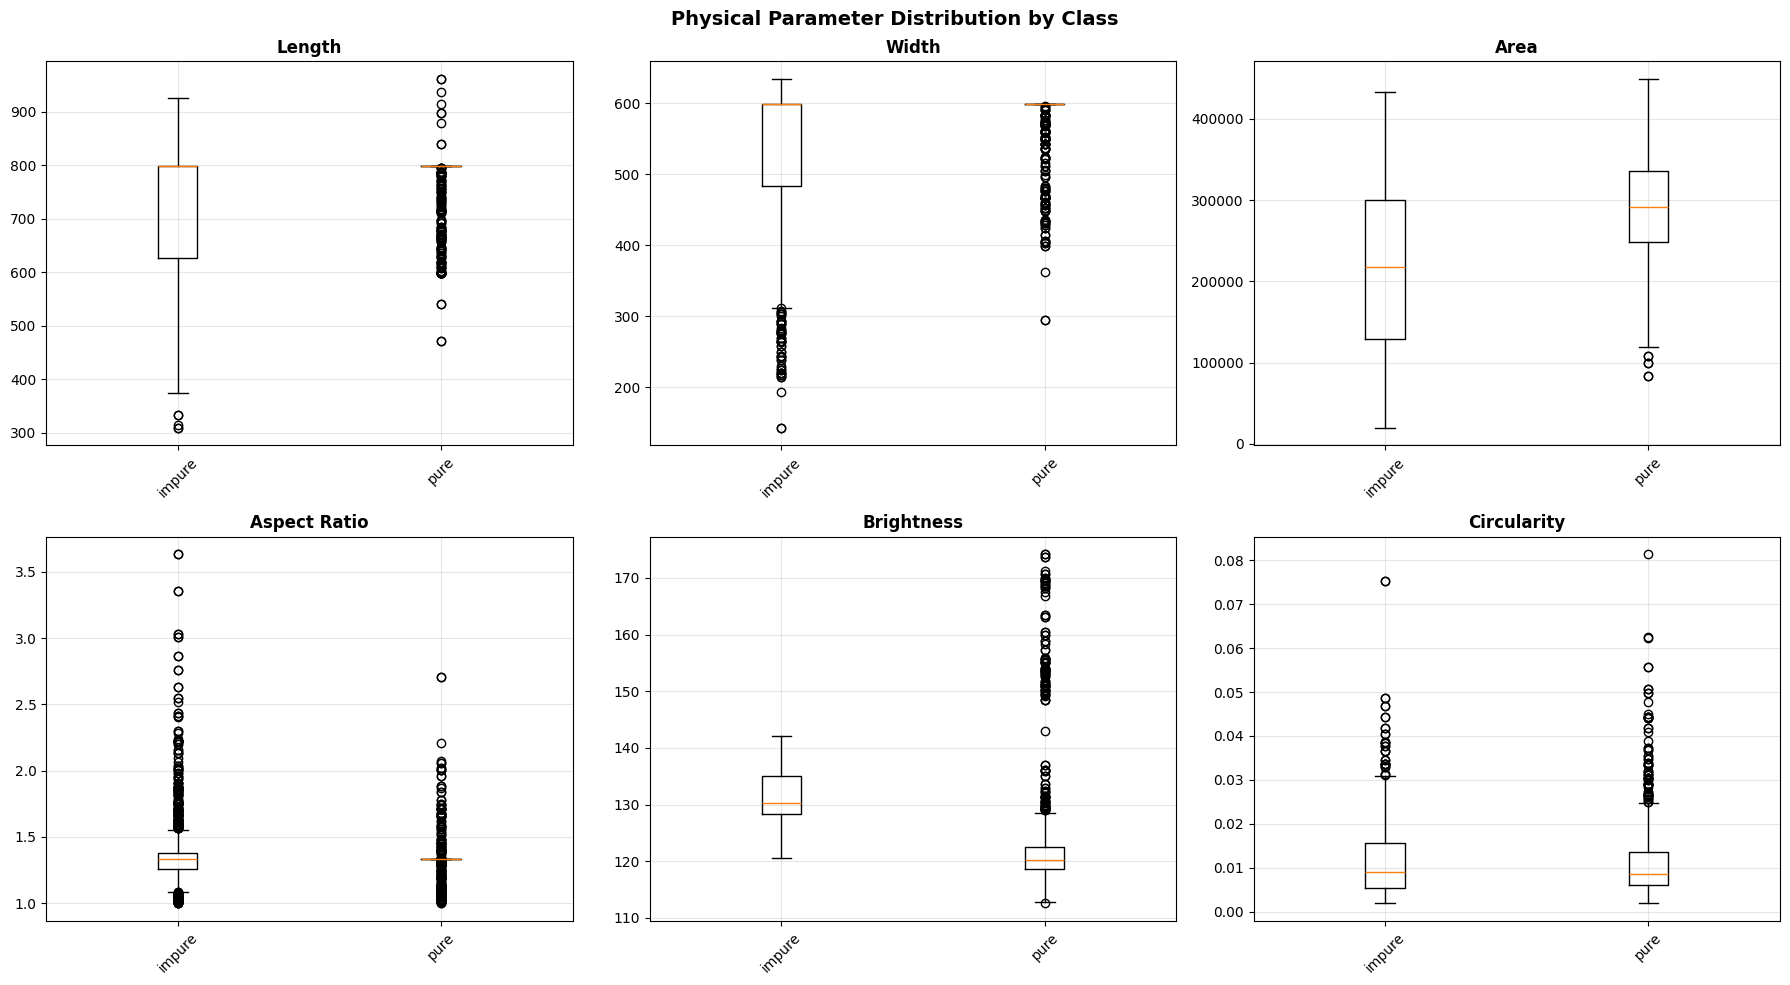

In [8]:
# CELL 7 ── Analyze Physical Parameters by Class
# ─────────────────────────────────────────────────────────────

def analyze_physical_parameters():
    """Analyze and visualize physical parameters across classes."""
    print("\n" + "="*70)
    print("  PHYSICAL PARAMETER ANALYSIS BY CLASS")
    print("="*70)
    
    # Collect parameters by class
    class_params = {cls: defaultdict(list) for cls in CLASS_NAMES}
    
    for idx in range(len(train_dataset)):
        _, label, params = train_dataset[idx]
        class_name = CLASS_NAMES[label]
        for key, value in params.items():
            class_params[class_name][key].append(value)
    
    # Calculate statistics
    print(f"\n{'Parameter':<20} | {'Class':<30} | {'Mean':<12} | {'Std':<12}")
    print("-" * 80)
    
    key_params = ['length', 'width', 'area', 'aspect_ratio', 
                  'brightness', 'circularity']
    
    for param in key_params:
        for cls in CLASS_NAMES:
            values = class_params[cls][param]
            if values:
                mean_val = np.mean(values)
                std_val = np.std(values)
                print(f"{param:<20} | {cls:<30} | {mean_val:>10.2f} | {std_val:>10.2f}")
    
    # Visualize key parameters
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, param in enumerate(key_params):
        data = [class_params[cls][param] for cls in CLASS_NAMES]
        axes[idx].boxplot(data, labels=CLASS_NAMES)
        axes[idx].set_title(f'{param.replace("_", " ").title()}', 
                           fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Physical Parameter Distribution by Class', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("="*70)

analyze_physical_parameters()


# ─────────────────────────────────────────────────────────────


In [9]:
# CELL 8 ── ResNet50 Model Builder
# ─────────────────────────────────────────────────────────────

def build_resnet50_model(num_classes=NUM_CLASSES, freeze_backbone=True):
    """
    Build ResNet50 model with transfer learning.
    Pre-trained on ImageNet with custom classification head.
    """
    print(f"\n🏗️  Building ResNet50 model...")
    
    # Load pre-trained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Freeze backbone if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        print("    ✅  Backbone frozen (transfer learning)")
    
    # Replace classification head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.4),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    
    model = model.to(DEVICE)
    
    # Count parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    
    print(f"    Architecture: ResNet50")
    print(f"    Trainable params: {trainable:,} / {total:,}")
    print(f"    Pre-trained: ImageNet")
    
    return model

# ── Build model
ARCHITECTURE = "resnet50"
model = build_resnet50_model(freeze_backbone=True)


# ─────────────────────────────────────────────────────────────



🏗️  Building ResNet50 model...
    ✅  Backbone frozen (transfer learning)
    Architecture: ResNet50
    Trainable params: 1,182,466 / 24,690,498
    Pre-trained: ImageNet


In [10]:
# CELL 9 ── Training Configuration
# ─────────────────────────────────────────────────────────────

# ── Hyperparameters
LEARNING_RATE = 1e-3
EPOCHS_FROZEN = 5
EPOCHS_FINETUNE = 20
WEIGHT_DECAY = 1e-4
SCHEDULER_STEP = 7
SCHEDULER_GAMMA = 0.1

# ── Loss function
criterion = nn.CrossEntropyLoss()

# ── Optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ── Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer,
                                      step_size=SCHEDULER_STEP,
                                      gamma=SCHEDULER_GAMMA)

print("\n⚙️  Training Configuration:")
print(f"    Learning Rate: {LEARNING_RATE}")
print(f"    Batch Size: {BATCH_SIZE}")
print(f"    Phase 1 (Frozen): {EPOCHS_FROZEN} epochs")
print(f"    Phase 2 (Fine-tune): {EPOCHS_FINETUNE} epochs")
print(f"    Weight Decay: {WEIGHT_DECAY}")
print(f"    Optimizer: Adam")


# ─────────────────────────────────────────────────────────────



⚙️  Training Configuration:
    Learning Rate: 0.001
    Batch Size: 32
    Phase 1 (Frozen): 5 epochs
    Phase 2 (Fine-tune): 20 epochs
    Weight Decay: 0.0001
    Optimizer: Adam


In [11]:
# CELL 10 ── Training & Validation Functions
# ─────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer):
    """Train for one epoch."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels, params in tqdm(loader, desc="  Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total


def validate(model, loader, criterion):
    """Validate the model."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels, params in tqdm(loader, desc="  Validating", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / total
    accuracy = correct / total
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    
    return avg_loss, accuracy, prec, rec, f1


def run_training(model, epochs, phase_name="Training"):
    """Run training for specified epochs."""
    best_acc = 0.0
    best_model = copy.deepcopy(model.state_dict())
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "precision": [], "recall": [], "f1": []
    }
    
    print(f"\n{'='*70}")
    print(f"  {phase_name}  |  Epochs: {epochs}  |  Device: {DEVICE}")
    print(f"{'='*70}")
    
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, prec, rec, f1 = validate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t0
        
        # Log metrics
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["precision"].append(prec)
        history["recall"].append(rec)
        history["f1"].append(f1)
        
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch [{epoch:02d}/{epochs}]  "
              f"Loss: {tr_loss:.4f}/{vl_loss:.4f}  "
              f"Acc: {tr_acc*100:.1f}%/{vl_acc*100:.1f}%  "
              f"F1: {f1:.3f}  LR: {lr_now:.2e}  ({elapsed:.1f}s)")
        
        if vl_acc > best_acc:
            best_acc = vl_acc
            best_model = copy.deepcopy(model.state_dict())
            torch.save(best_model, "best_resnet50_paddy_model.pth")
            print(f"    ✅  New best val accuracy: {best_acc*100:.2f}%")
    
    print(f"\n🏆  Best Validation Accuracy: {best_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return history


# ─────────────────────────────────────────────────────────────


In [12]:
# CELL 11 ── Phase 1: Train Classification Head Only
# ─────────────────────────────────────────────────────────────

print("\n⏳  PHASE 1: Training classification head (backbone frozen)")
history_frozen = run_training(model, epochs=EPOCHS_FROZEN,
                             phase_name="Phase 1 — Head Training")


# ─────────────────────────────────────────────────────────────



⏳  PHASE 1: Training classification head (backbone frozen)

  Phase 1 — Head Training  |  Epochs: 5  |  Device: cuda


  Epoch [01/5]  Loss: 0.2289/0.1894  Acc: 90.3%/90.3%  F1: 0.903  LR: 1.00e-03  (28.5s)
    ✅  New best val accuracy: 90.33%


  Epoch [02/5]  Loss: 0.1504/0.1485  Acc: 94.8%/94.3%  F1: 0.943  LR: 1.00e-03  (28.2s)
    ✅  New best val accuracy: 94.33%


  Epoch [03/5]  Loss: 0.1303/0.0666  Acc: 94.6%/99.0%  F1: 0.990  LR: 1.00e-03  (28.2s)
    ✅  New best val accuracy: 99.00%


  Epoch [04/5]  Loss: 0.1442/0.0952  Acc: 94.7%/95.7%  F1: 0.957  LR: 1.00e-03  (29.7s)


  Epoch [05/5]  Loss: 0.0933/0.0467  Acc: 96.4%/99.3%  F1: 0.993  LR: 1.00e-03  (28.3s)
    ✅  New best val accuracy: 99.33%

🏆  Best Validation Accuracy: 99.33%


In [13]:
# CELL 12 ── Phase 2: Fine-tune Entire Network
# ─────────────────────────────────────────────────────────────

print("\n⏳  PHASE 2: Fine-tuning entire ResNet50")

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE * 0.1,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.StepLR(optimizer,
                                      step_size=SCHEDULER_STEP,
                                      gamma=SCHEDULER_GAMMA)

history_finetune = run_training(model, epochs=EPOCHS_FINETUNE,
                                phase_name="Phase 2 — Full Fine-tuning")

# Merge histories
full_history = {k: history_frozen[k] + history_finetune[k]
                for k in history_frozen}


# ─────────────────────────────────────────────────────────────



⏳  PHASE 2: Fine-tuning entire ResNet50

  Phase 2 — Full Fine-tuning  |  Epochs: 20  |  Device: cuda


  Epoch [01/20]  Loss: 0.0779/0.0114  Acc: 97.4%/100.0%  F1: 1.000  LR: 1.00e-04  (33.7s)
    ✅  New best val accuracy: 100.00%


  Epoch [02/20]  Loss: 0.0468/0.0092  Acc: 98.2%/99.7%  F1: 0.997  LR: 1.00e-04  (33.2s)


  Epoch [03/20]  Loss: 0.0185/0.0043  Acc: 99.4%/100.0%  F1: 1.000  LR: 1.00e-04  (34.1s)


  Epoch [04/20]  Loss: 0.0359/0.0012  Acc: 98.7%/100.0%  F1: 1.000  LR: 1.00e-04  (32.8s)


...

  Epoch [16/20]  Loss: 0.0101/0.0003  Acc: 99.8%/100.0%  F1: 1.000  LR: 1.00e-06  (34.6s)


  Epoch [17/20]  Loss: 0.0083/0.0003  Acc: 99.7%/100.0%  F1: 1.000  LR: 1.00e-06  (33.5s)


  Epoch [18/20]  Loss: 0.0115/0.0003  Acc: 99.6%/100.0%  F1: 1.000  LR: 1.00e-06  (34.3s)


  Epoch [19/20]  Loss: 0.0130/0.0005  Acc: 99.6%/100.0%  F1: 1.000  LR: 1.00e-06  (33.1s)


  Epoch [20/20]  Loss: 0.0072/0.0003  Acc: 99.9%/100.0%  F1: 1.000  LR: 1.00e-06  (34.6s)

🏆  Best Validation Accuracy: 100.00%


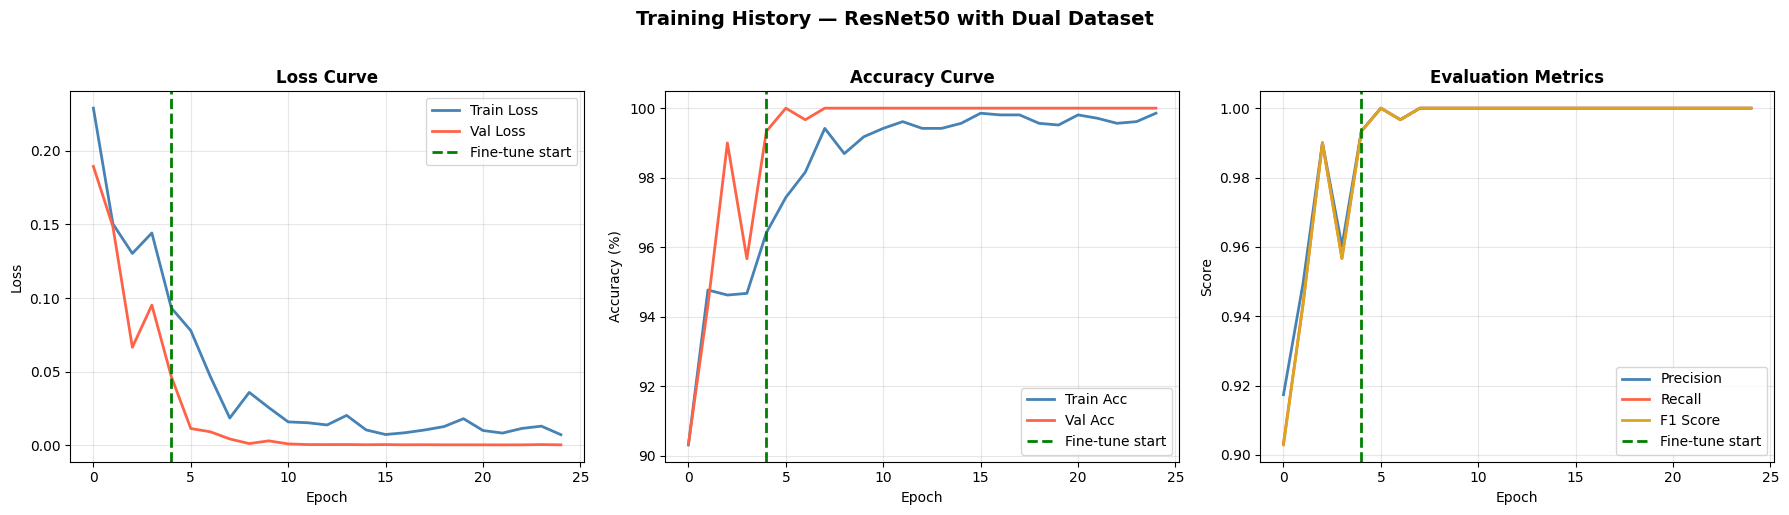

In [14]:
# CELL 13 ── Training Visualization
# ─────────────────────────────────────────────────────────────

def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue", linewidth=2)
    axes[0].plot(history["val_loss"], label="Val Loss", color="tomato", linewidth=2)
    axes[0].axvline(x=EPOCHS_FROZEN - 1, color="green",
                   linestyle="--", label="Fine-tune start", linewidth=2)
    axes[0].set_title("Loss Curve", fontweight="bold", fontsize=12)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Accuracy
    axes[1].plot([a*100 for a in history["train_acc"]], label="Train Acc",
                color="steelblue", linewidth=2)
    axes[1].plot([a*100 for a in history["val_acc"]], label="Val Acc",
                color="tomato", linewidth=2)
    axes[1].axvline(x=EPOCHS_FROZEN - 1, color="green",
                   linestyle="--", label="Fine-tune start", linewidth=2)
    axes[1].set_title("Accuracy Curve", fontweight="bold", fontsize=12)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Metrics
    axes[2].plot(history["precision"], label="Precision", color="steelblue", linewidth=2)
    axes[2].plot(history["recall"], label="Recall", color="tomato", linewidth=2)
    axes[2].plot(history["f1"], label="F1 Score", color="goldenrod", linewidth=2)
    axes[2].axvline(x=EPOCHS_FROZEN - 1, color="green",
                   linestyle="--", label="Fine-tune start", linewidth=2)
    axes[2].set_title("Evaluation Metrics", fontweight="bold", fontsize=12)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.suptitle(f"Training History — ResNet50 with Dual Dataset",
                fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_history(full_history)


# ─────────────────────────────────────────────────────────────



  COMPREHENSIVE TEST SET EVALUATION


Testing: 100%|██████████| 13/13 [00:03<00:00,  3.41it/s]



📊  CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      impure     1.0000    1.0000    1.0000       204
        pure     1.0000    1.0000    1.0000       209

    accuracy                         1.0000       413
   macro avg     1.0000    1.0000    1.0000       413
weighted avg     1.0000    1.0000    1.0000       413


🎯  OVERALL METRICS:
──────────────────────────────────────────────────────────────────────
  Accuracy   : 100.00%
  Precision  : 100.00%
  Recall     : 100.00%
  F1 Score   : 100.00%
──────────────────────────────────────────────────────────────────────

📈  PER-CLASS PERFORMANCE:
──────────────────────────────────────────────────────────────────────
Class                               Precision    Recall       F1-Score    
──────────────────────────────────────────────────────────────────────
impure                                  100.00%      100.00%      100.00%
pure                                    100.00%      100.00%      100.00%

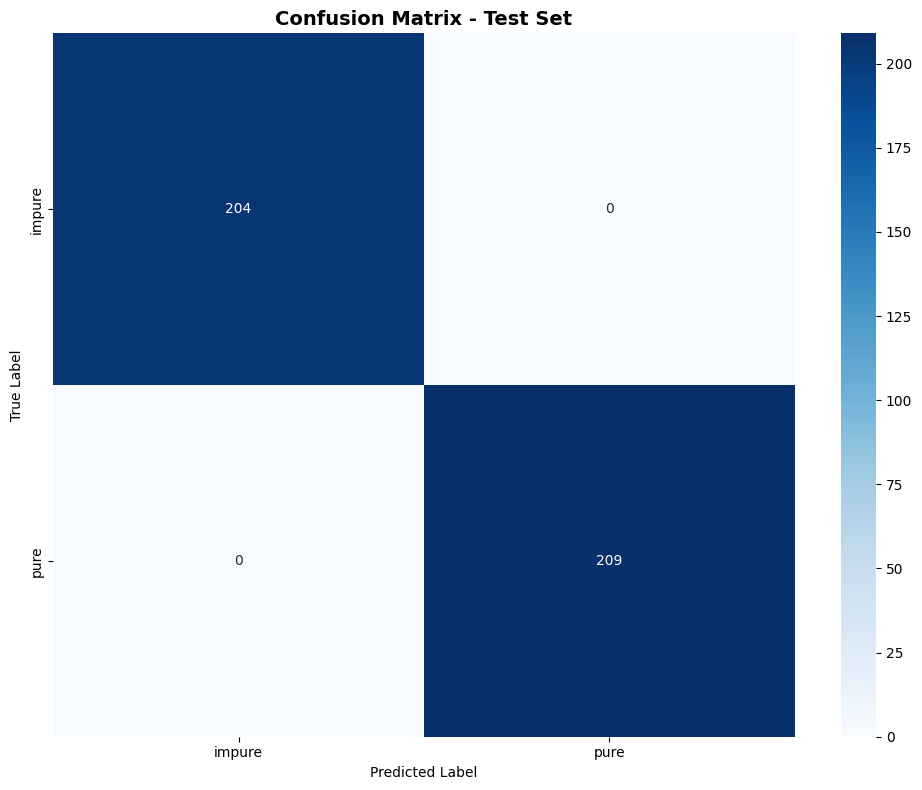


🔍  MISCLASSIFICATION ANALYSIS:
──────────────────────────────────────────────────────────────────────
  Total misclassifications: 0 / 413
  Misclassification rate: 0.00%
──────────────────────────────────────────────────────────────────────


In [15]:
# CELL 14 ── Comprehensive Testing & Evaluation
# ─────────────────────────────────────────────────────────────

def comprehensive_test_evaluation(model, test_loader):
    """Comprehensive test set evaluation with detailed metrics."""
    print("\n" + "="*70)
    print("  COMPREHENSIVE TEST SET EVALUATION")
    print("="*70)
    
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_params = defaultdict(list)
    
    with torch.no_grad():
        for images, labels, params in tqdm(test_loader, desc="Testing"):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            
            # Collect physical parameters
            for key, value in params.items():
                all_params[key].extend(value.numpy())
    
    # Classification Report
    print("\n📊  CLASSIFICATION REPORT:")
    print("="*70)
    print(classification_report(all_labels, all_preds,
                               target_names=CLASS_NAMES, digits=4))
    
    # Overall Metrics
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    
    print(f"\n🎯  OVERALL METRICS:")
    print(f"{'─'*70}")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  Precision  : {prec*100:.2f}%")
    print(f"  Recall     : {rec*100:.2f}%")
    print(f"  F1 Score   : {f1*100:.2f}%")
    print(f"{'─'*70}")
    
    # Per-Class Metrics
    print(f"\n📈  PER-CLASS PERFORMANCE:")
    print(f"{'─'*70}")
    print(f"{'Class':<35} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print(f"{'─'*70}")
    
    for i, cls in enumerate(CLASS_NAMES):
        class_preds = [p for p, l in zip(all_preds, all_labels) if l == i]
        class_labels = [l for l in all_labels if l == i]
        
        if class_labels:
            cls_prec = precision_score([i]*len(class_labels), class_preds, 
                                       labels=[i], average='weighted', zero_division=0)
            cls_rec = recall_score([i]*len(class_labels), class_preds,
                                  labels=[i], average='weighted', zero_division=0)
            cls_f1 = f1_score([i]*len(class_labels), class_preds,
                             labels=[i], average='weighted', zero_division=0)
            
            print(f"{cls:<35} {cls_prec*100:>10.2f}%  {cls_rec*100:>10.2f}%  {cls_f1*100:>10.2f}%")
    
    print(f"{'─'*70}")
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Test Set', fontweight='bold', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Analyze misclassifications with physical parameters
    print(f"\n🔍  MISCLASSIFICATION ANALYSIS:")
    print(f"{'─'*70}")
    misclass_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
    print(f"  Total misclassifications: {len(misclass_indices)} / {len(all_labels)}")
    print(f"  Misclassification rate: {len(misclass_indices)/len(all_labels)*100:.2f}%")
    
    if misclass_indices:
        print(f"\n  Physical parameter analysis of misclassified samples:")
        for param in ['length', 'width', 'aspect_ratio', 'brightness']:
            correct_vals = [all_params[param][i] for i in range(len(all_labels))
                          if i not in misclass_indices]
            misclass_vals = [all_params[param][i] for i in misclass_indices]
            
            if correct_vals and misclass_vals:
                print(f"    {param:<20}: Correct μ={np.mean(correct_vals):.2f}  "
                      f"Misclass μ={np.mean(misclass_vals):.2f}")
    
    print(f"{'─'*70}")
    
    return all_labels, all_preds, np.array(all_probs)

# Run comprehensive testing
test_labels, test_preds, test_probs = comprehensive_test_evaluation(model, test_loader)


# ─────────────────────────────────────────────────────────────


In [16]:
# CELL 15 ── Model Predictions with Physical Parameters
# ─────────────────────────────────────────────────────────────

def predict_with_parameters(image_path, model, show_params=True):
    """
    Predict seed class and show physical parameters.
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    
    # Extract physical parameters
    params = param_extractor.extract_parameters(image_path)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        pred_class = CLASS_NAMES[pred_idx]
        pred_prob = probs[pred_idx].item()
    
    # Display results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Show image
    axes[0].imshow(img)
    axes[0].set_title(f"Predicted: {pred_class}\nConfidence: {pred_prob*100:.1f}%",
                     fontweight='bold', fontsize=12)
    axes[0].axis('off')
    
    # Show probabilities
    bars = axes[1].barh(CLASS_NAMES, [probs[i].item()*100 for i in range(NUM_CLASSES)])
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_title('Class Probabilities', fontweight='bold', fontsize=12)
    axes[1].set_xlim([0, 100])
    
    # Color the predicted class
    bars[pred_idx].set_color('green')
    
    plt.tight_layout()
    plt.show()
    
    # Show physical parameters if requested
    if show_params:
        print(f"\n{'='*70}")
        print(f"  PHYSICAL PARAMETERS")
        print(f"{'='*70}")
        print(f"  Dimensional:")
        print(f"    Length: {params['length']:.2f} px")
        print(f"    Width: {params['width']:.2f} px")
        print(f"    Area: {params['area']:.2f} px²")
        print(f"    Aspect Ratio: {params['aspect_ratio']:.2f}")
        print(f"\n  Color:")
        print(f"    Brightness: {params['brightness']:.2f}")
        print(f"    Mean RGB: ({params['mean_red']:.1f}, "
              f"{params['mean_green']:.1f}, {params['mean_blue']:.1f})")
        print(f"\n  Shape:")
        print(f"    Circularity: {params['circularity']:.3f}")
        print(f"    Solidity: {params['solidity']:.3f}")
        print(f"{'='*70}")
    
    return {
        'prediction': pred_class,
        'confidence': pred_prob,
        'probabilities': {CLASS_NAMES[i]: probs[i].item() 
                         for i in range(NUM_CLASSES)},
        'physical_parameters': params
    }


# ─────────────────────────────────────────────────────────────


In [17]:
# CELL 16 ── Save Model and Generate Summary Report
# ─────────────────────────────────────────────────────────────

def save_model(model, path="resnet50_paddy_dual_dataset.pth"):
    """Save the trained model."""
    torch.save({
        "architecture": ARCHITECTURE,
        "num_classes": NUM_CLASSES,
        "class_names": CLASS_NAMES,
        "state_dict": model.state_dict(),
        "train_history": full_history,
    }, path)
    print(f"✅  Model saved to: {path}")


def generate_summary_report():
    """Generate comprehensive training summary."""
    print("\n" + "█"*70)
    print("  PADDY SEED DETECTION — FINAL SUMMARY REPORT")
    print("  ResNet50 with Dual Dataset & Physical Parameters")
    print("█"*70)
    
    print(f"\n{'─'*70}")
    print(f"  MODEL ARCHITECTURE")
    print(f"{'─'*70}")
    print(f"  Architecture       : ResNet50")
    print(f"  Input Resolution   : {IMAGE_SIZE} × {IMAGE_SIZE} pixels")
    print(f"  Transfer Learning  : ✅  Pre-trained on ImageNet")
    print(f"  Classes            : {NUM_CLASSES}")
    for i, c in enumerate(CLASS_NAMES):
        print(f"    [{i}] {c}")
    
    print(f"\n{'─'*70}")
    print(f"  DATASET CONFIGURATION")
    print(f"{'─'*70}")
    print(f"  Source 1           : ayyanarkadalkani/paddy-seeds-quality")
    print(f"  Source 2           : Paddy Seed Image Dataset")
    print(f"  Combined Training  : {len(train_dataset)} images")
    print(f"  Validation Set     : {len(val_dataset)} images")
    print(f"  Test Set           : {len(test_dataset)} images")
    
    print(f"\n{'─'*70}")
    print(f"  PHYSICAL PARAMETERS EXTRACTED")
    print(f"{'─'*70}")
    print(f"  Dimensional        : Length, Width, Area, Perimeter, Aspect Ratio")
    print(f"  Color Features     : Mean RGB, Std RGB, Brightness")
    print(f"  Shape Descriptors  : Circularity, Solidity, Convexity")
    print(f"  Texture Features   : Variance, Entropy")
    
    print(f"\n{'─'*70}")
    print(f"  TRAINING CONFIGURATION")
    print(f"{'─'*70}")
    print(f"  Optimizer          : Adam")
    print(f"  Initial LR         : {LEARNING_RATE}")
    print(f"  Fine-tune LR       : {LEARNING_RATE * 0.1}")
    print(f"  Batch Size         : {BATCH_SIZE}")
    print(f"  Phase-1 Epochs     : {EPOCHS_FROZEN} (head only)")
    print(f"  Phase-2 Epochs     : {EPOCHS_FINETUNE} (full fine-tune)")
    print(f"  Total Epochs       : {EPOCHS_FROZEN + EPOCHS_FINETUNE}")
    print(f"  Weight Decay       : {WEIGHT_DECAY}")
    print(f"  Data Augmentation  : Flip, Rotate, Crop, ColorJitter, Affine")
    
    print(f"\n{'─'*70}")
    print(f"  FINAL TEST METRICS")
    print(f"{'─'*70}")
    acc = accuracy_score(test_labels, test_preds)
    prec = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
    rec = recall_score(test_labels, test_preds, average="weighted", zero_division=0)
    f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    
    print(f"  Accuracy           : {acc*100:.2f}%")
    print(f"  Precision          : {prec*100:.2f}%")
    print(f"  Recall             : {rec*100:.2f}%")
    print(f"  F1 Score           : {f1*100:.2f}%")
    
    print("\n" + "█"*70 + "\n")

# Save model and generate report
save_model(model)
generate_summary_report()


# ─────────────────────────────────────────────────────────────


✅  Model saved to: resnet50_paddy_dual_dataset.pth

██████████████████████████████████████████████████████████████████████
  PADDY SEED DETECTION — FINAL SUMMARY REPORT
  ResNet50 with Dual Dataset & Physical Parameters
██████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────────────
  MODEL ARCHITECTURE
──────────────────────────────────────────────────────────────────────
  Architecture       : ResNet50
  Input Resolution   : 224 × 224 pixels
  Transfer Learning  : ✅  Pre-trained on ImageNet
  Classes            : 2
    [0] impure
    [1] pure

──────────────────────────────────────────────────────────────────────
  DATASET CONFIGURATION
──────────────────────────────────────────────────────────────────────
  Source 1           : ayyanarkadalkani/paddy-seeds-quality
  Source 2           : Paddy Seed Image Dataset
  Combined Training  : 2064 images
  Validation Set     : 300 images
  Test Set           : 413

In [18]:
# CELL 17 ── Usage Examples
# ─────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("  USAGE EXAMPLES")
print("="*70)
print("""
# ── Predict a single image with DUS and physical parameters
result = predict_with_dus_parameters("path/to/seed_image.jpg", model, param_extractor)

# ── Load model later
checkpoint = torch.load("resnet50_paddy_dual_dataset.pth")
loaded_model = build_resnet50_model(num_classes=checkpoint["num_classes"], 
                                    freeze_backbone=False)
loaded_model.load_state_dict(checkpoint["state_dict"])
loaded_model.eval()

# ── Download model in Colab
from google.colab import files
files.download("resnet50_paddy_dual_dataset.pth")

# ── Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
""")
print("="*70)

print("\n✅  Training complete! Model ready for deployment.")



  USAGE EXAMPLES

# ── Predict a single image with DUS and physical parameters
result = predict_with_dus_parameters("path/to/seed_image.jpg", model, param_extractor)

# ── Load model later
checkpoint = torch.load("resnet50_paddy_dual_dataset.pth")
loaded_model = build_resnet50_model(num_classes=checkpoint["num_classes"], 
                                    freeze_backbone=False)
loaded_model.load_state_dict(checkpoint["state_dict"])
loaded_model.eval()

# ── Download model in Colab
from google.colab import files
files.download("resnet50_paddy_dual_dataset.pth")

# ── Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


✅  Training complete! Model ready for deployment.
